# Análise de risco de crédito

In [9]:
!pip install shap -q

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_clients = pd.read_csv('/content/drive/MyDrive/Iago-pessoal/projects_python/clientes.csv')
display(df_clients)

,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.465380,alto_gasto_pagamento_baixos,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.465380,baixo_gasto_pagamento_alto,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.465380,baixo_gasto_pagamento_medio,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.465380,baixo_gasto_pagamento_baixo,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.465380,alto_gasto_pagamento_medio,341.489231,Good,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,23.0,...,378.0,24.028477,alto_gasto_pagamento_alto,479.866228,Poor,1,0,0,0,1
99996,37932,5,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,18.0,...,379.0,24.028477,alto_gasto_pagamento_medio,496.651610,Poor,1,0,0,0,1
99997,37932,6,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,27.0,...,380.0,24.028477,alto_gasto_pagamento_alto,516.809083,Poor,1,0,0,0,1
99998,37932,7,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,20.0,...,381.0,24.028477,baixo_gasto_pagamento_alto,319.164979,Standard,1,0,0,0,1


In [5]:
# @title Construindo o Pipeline de Pré-processamento
# 1. Separar as variáveis explicativas (X) da variável alvo (y)
X = df_clients.drop(columns=['score_credito', 'id_cliente'])
y = df_clients['score_credito']

# 2. Dividir os dados ANTES de qualquer transformação para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 3. Identificar as colunas numéricas e categóricas
cols_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_categoricas = X_train.select_dtypes(include=['object']).columns.tolist()

# 4. Criar os transformadores específicos para cada tipo de dado
transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche valores nulos numéricos com a mediana
    ('scaler', StandardScaler())                   # Padroniza a escala (essencial para o KNN)
])

transformador_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Preenche nulos com a moda
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # Transforma categorias em colunas binárias
])

# 5. Unir tudo no ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, cols_numericas),
        ('cat', transformador_categorico, cols_categoricas)
    ])

In [6]:
# @title Acoplando o Modelo e Treinando
# Criar o pipeline final com o Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', pre_processador),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Criar o pipeline final com o KNN
pipeline_knn = Pipeline(steps=[
    ('preprocessor', pre_processador),
    ('classifier', KNeighborsClassifier())
])

# Treinar os modelos (o pré-processamento ocorre internamente aqui!)
pipeline_rf.fit(X_train, y_train)
pipeline_knn.fit(X_train, y_train)

# Avaliar os modelos
y_pred_rf = pipeline_rf.predict(X_test)
print("--- Desempenho do Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Desempenho do Random Forest ---
              precision    recall  f1-score   support

        Good       0.80      0.79      0.79      4457
        Poor       0.81      0.85      0.83      7250
    Standard       0.85      0.83      0.84     13293

    accuracy                           0.83     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.83      0.83      0.83     25000



In [7]:
# Carregar novos clientes
df_new_clients = pd.read_csv('/content/drive/MyDrive/Iago-pessoal/projects_python/novos_clientes.csv')

# Prever diretamente usando o pipeline treinado (sem precisar tratar os dados manualmente antes!)
novas_previsoes = pipeline_rf.predict(df_new_clients)
display(novas_previsoes)

array(['Poor', 'Standard', 'Standard'], dtype=object)

# Otimização de Hiperparâmetros
Aqui a ideia é testar várias combinações de "configurações" do Random Forest para achar a que maximiza os acertos (focando no F1-Score para evitar viés)

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Definir o espaço de busca (quais parâmetros o algoritmo vai testar)
param_dist = {
    'classifier__n_estimators': [100, 200, 300],          # Número de árvores
    'classifier__max_depth': [10, 20, 30, None],          # Profundidade máxima de cada árvore
    'classifier__min_samples_split': [2, 5, 10],          # Mínimo de amostras para dividir um nó
    'classifier__class_weight': ['balanced', None]        # 'balanced' é ótimo para bases desbalanceadas
}

# 2. Configurar o buscador automático
random_search = RandomizedSearchCV(
    pipeline_rf,                  # pipeline criado anteriormente
    param_distributions=param_dist,
    n_iter=10,                    # Vai testar 10 combinações aleatórias
    cv=3,                         # Validação cruzada (divide os dados em 3 partes para testar)
    scoring='f1_macro',           # Foca na média do F1-Score (importante para crédito)
    random_state=42,
    n_jobs=-1                     # Usa todos os núcleos do processador do Colab para ir mais rápido
)

# 3. Iniciar o treinamento (demora um bocado)
print("Iniciando a busca pelos melhores hiperparâmetros...")
random_search.fit(X_train, y_train)

print("\nConcluído! Melhores parâmetros encontrados:")
print(random_search.best_params_)

# 4. Salvamos a melhor versão do modelo em uma variável
melhor_modelo_rf = random_search.best_estimator_

Iniciando a busca pelos melhores hiperparâmetros...

Concluído! Melhores parâmetros encontrados:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}


# Explicabilidade do Modelo
O SHAP vai gerar gráficos mostrando exatamente o peso de cada variável na decisão. Ele vai permitir que seja dito: "O crédito do Cliente X foi classificado como 'Poor' principalmente porque a taxa_uso_credito estava em 85% e ele possuía 5 num_emprestimos ativos, superando o peso positivo do seu salario_anual"

Gerando gráfico de impacto das variáveis...


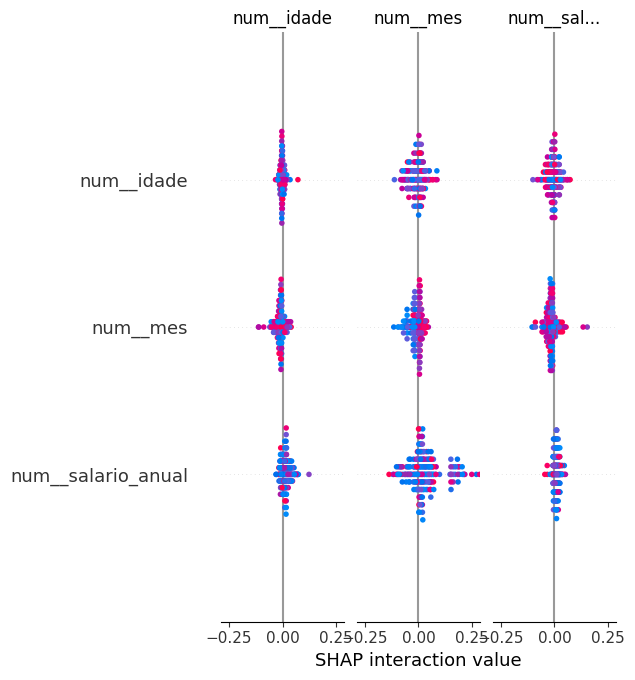

In [11]:
import shap

# 1. Extrair as partes do nosso pipeline vencedor
modelo_arvore = melhor_modelo_rf.named_steps['classifier']
pre_processador_treinado = melhor_modelo_rf.named_steps['preprocessor']

# 2. Transformar uma amostra dos dados (o modelo lê números, não textos)
X_test_transformado = pre_processador_treinado.transform(X_test)

# 3. Pegar os nomes corretos das colunas após o pré-processamento (OneHotEncoder gera novas colunas)
nomes_features = pre_processador_treinado.get_feature_names_out()
X_test_shap = pd.DataFrame(X_test_transformado, columns=nomes_features)

# 4. Iniciar o SHAP Explainer
explainer = shap.TreeExplainer(modelo_arvore)

# Vamos pegar uma amostra de 200 clientes para calcular mais rápido
amostra_shap = X_test_shap.sample(200, random_state=42)
shap_values = explainer.shap_values(amostra_shap)

# 5. Plotar o gráfico de impacto (Summary Plot)
print("Gerando gráfico de impacto das variáveis...")
shap.summary_plot(shap_values, amostra_shap)

# Versionamento e MLOps (Salvando o modelo)

Esta é a etapa em que reuniu-se toda o modelo (regras de preenchimento de nulos, OneHotEncoder, modelo tunado) e comprimiu-se em um arquivo só.

In [12]:
import joblib
nome_arquivo_modelo = '/content/drive/MyDrive/Iago-pessoal/projects_python/modelo_risco_credito_v1.pkl'

# Salvar o objeto do pipeline completo
joblib.dump(melhor_modelo_rf, nome_arquivo_modelo)

print(f"✅ Modelo de produção salvo com sucesso em:\n{nome_arquivo_modelo}")
print("Este arquivo .pkl pode ser carregado em uma API (ex: FastAPI ou Flask) para classificar clientes em tempo real.")

✅ Modelo de produção salvo com sucesso em:
/content/drive/MyDrive/Iago-pessoal/projects_python/modelo_risco_credito_v1.pkl
Este arquivo .pkl pode ser carregado em uma API (ex: FastAPI ou Flask) para classificar clientes em tempo real.


In [16]:
# métricas:

#accuracy
print(accuracy_score(y_test, y_pred_rf))

#precision
#recall
#f1-score
print(classification_report(y_test, y_pred_rf))

0.82764
              precision    recall  f1-score   support

        Good       0.80      0.79      0.79      4457
        Poor       0.81      0.85      0.83      7250
    Standard       0.85      0.83      0.84     13293

    accuracy                           0.83     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.83      0.83      0.83     25000



# Relatórios Gerenciais (Exportando Base Final)
Aqui foi lido o arquivo de novos clientes, prevemos o score deles, calculamos a % de confiança matemática do modelo e foi tudo exportado para um CSV limpo, pronto para ser jogado no Power BI ou Looker Studio.

In [13]:

df_new_clients = pd.read_csv('/content/drive/MyDrive/Iago-pessoal/projects_python/novos_clientes.csv')


previsoes_finais = melhor_modelo_rf.predict(df_new_clients)

# Pegar a probabilidade/confiança do modelo (ex: "85% de certeza que é Poor")
probabilidades = melhor_modelo_rf.predict_proba(df_new_clients)
confianca_predicao = probabilidades.max(axis=1) # Pega a maior probabilidade de cada linha

# Criar um novo DataFrame focado no relatório gerencial
df_relatorio = df_new_clients.copy()
df_relatorio['Score_Previsto'] = previsoes_finais
df_relatorio['Confianca_IA_(%)'] = (confianca_predicao * 100).round(2)

# Exibir os primeiros resultados para conferir
print("Amostra das predições finalizadas:")
display(df_relatorio[['idade', 'profissao', 'dias_atraso', 'Score_Previsto', 'Confianca_IA_(%)']].head())

# Exportar para CSV
caminho_exportacao = '/content/drive/MyDrive/Iago-pessoal/projects_python/relatorio_novos_clientes_escorados.csv'
df_relatorio.to_csv(caminho_exportacao, index=False)

print(f"\n📊 Base pronta para visualização! Salva em:\n{caminho_exportacao}")

Amostra das predições finalizadas:


,idade,profissao,dias_atraso,Score_Previsto,Confianca_IA_(%)
0,31.0,empresario,52.0,Poor,93.5
1,32.0,advogado,25.0,Standard,58.0
2,48.0,empresario,24.0,Standard,93.5



📊 Base pronta para visualização! Salva em:
/content/drive/MyDrive/Iago-pessoal/projects_python/relatorio_novos_clientes_escorados.csv
